In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [4]:


# Set seed for consistent results
np.random.seed(42)

# Generate 1000 entries for Study Hours (0 to 10)
hours = np.linspace(1, 10, 1000)

# Logistic model: Logit = -5 + 1 * Hours
# This creates a 50% pass probability at exactly 5.0 hours
logit = -5 + 1 * hours
prob = 1 / (1 + np.exp(-logit))

# Generate binary outcomes (0 or 1) based on the probability
pass_result = np.random.binomial(1, prob)

# Create DataFrame and export
df = pd.DataFrame({'Hours_Studied': hours, 'Pass_Result': pass_result})
df.to_csv('student_exam_data_1000.csv', index=False)

print("CSV file 'student_exam_data_1000.csv' has been created.")


CSV file 'student_exam_data_1000.csv' has been created.


In [5]:
df.head()

,Hours_Studied,Pass_Result
0,1.000000,0
1,1.009009,0
2,1.018018,0
3,1.027027,0
4,1.036036,0


In [6]:
df["Hours_Studied"].value_counts()

Hours_Studied
1.000000     1
1.009009     1
1.018018     1
1.027027     1
1.036036     1
            ..
9.963964     1
9.972973     1
9.981982     1
9.990991     1
10.000000    1
Name: count, Length: 1000, dtype: int64

In [7]:
df.describe()

,Hours_Studied,Pass_Result
count,1000.000000,1000.000000
mean,5.500000,0.555000
std,2.601977,0.497214
min,1.000000,0.000000
25%,3.250000,0.000000
50%,5.500000,1.000000
75%,7.750000,1.000000
max,10.000000,1.000000


In [8]:
df["Hours_Studied"]=df["Hours_Studied"].astype(int)

In [9]:
df.head()

,Hours_Studied,Pass_Result
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [10]:
df.iloc[:80]

,Hours_Studied,Pass_Result
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
...,...,...
75,1,0
76,1,0
77,1,0
78,1,0


In [11]:
df.tail()

,Hours_Studied,Pass_Result
995,9,1
996,9,1
997,9,1
998,9,1
999,10,1


In [12]:
df.isna().sum()

Hours_Studied    0
Pass_Result      0
dtype: int64

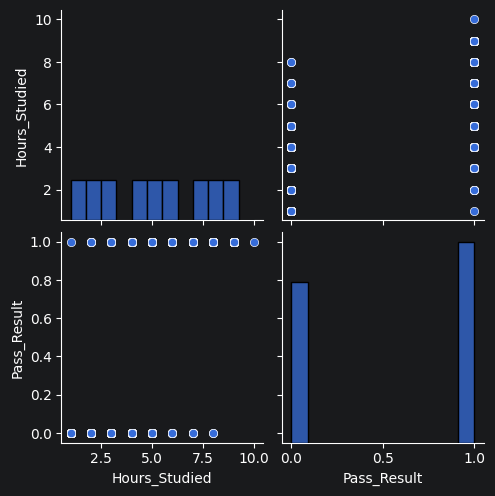

In [13]:
sns.pairplot(df)

In [14]:
from sklearn.model_selection import train_test_split
X=df[["Hours_Studied"]]
y=df["Pass_Result"]

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [16]:
model=LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
y_pred=model.predict(X_test)

In [18]:
y_pred

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0], d

In [19]:
y_prob=model.predict_proba(X_test)[:,1]

In [20]:
y_prob

array([0.63536699, 0.93556893, 0.93556893, 0.83416461, 0.37641043,
       0.93556893, 0.83416461, 0.63536699, 0.97669901, 0.06754293,
       0.97669901, 0.02447835, 0.83416461, 0.99180341, 0.99180341,
       0.99180341, 0.1729395 , 0.97669901, 0.93556893, 0.1729395 ,
       0.63536699, 0.06754293, 0.37641043, 0.63536699, 0.06754293,
       0.1729395 , 0.02447835, 0.99180341, 0.99180341, 0.99180341,
       0.37641043, 0.06754293, 0.83416461, 0.63536699, 0.37641043,
       0.06754293, 0.93556893, 0.83416461, 0.99180341, 0.02447835,
       0.1729395 , 0.02447835, 0.1729395 , 0.99180341, 0.1729395 ,
       0.1729395 , 0.99180341, 0.83416461, 0.37641043, 0.97669901,
       0.83416461, 0.97669901, 0.1729395 , 0.83416461, 0.02447835,
       0.02447835, 0.83416461, 0.02447835, 0.06754293, 0.97669901,
       0.1729395 , 0.02447835, 0.63536699, 0.06754293, 0.83416461,
       0.93556893, 0.83416461, 0.97669901, 0.02447835, 0.63536699,
       0.02447835, 0.63536699, 0.83416461, 0.93556893, 0.17293

Text(0.5, 1.0, 'Sigmoid Function Fit')

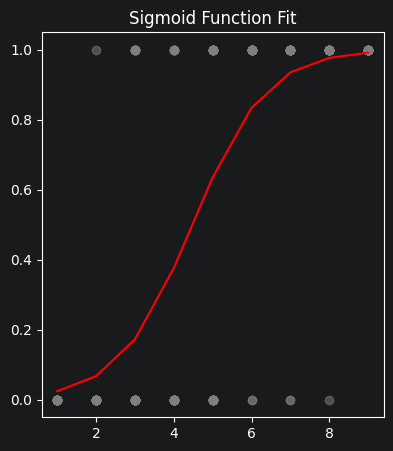

In [21]:
plt.figure(figsize=(15, 5))

# Plot A: Sigmoid Curve
plt.subplot(1, 3, 1)
plt.scatter(X_test, y_test, color='gray', alpha=0.5)
sorted_idx = np.argsort(X_test.values.flatten())
plt.plot(X_test.values[sorted_idx], y_prob[sorted_idx], color='red')
plt.title('Sigmoid Function Fit')

Text(0.5, 1.0, 'Confusion Matrix')

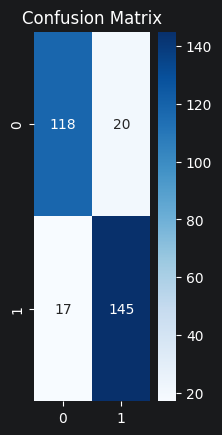

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
plt.subplot(1, 3, 2)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,fmt='d', cmap='Blues')
plt.title('Confusion Matrix')

Text(0.5, 23.52222222222222, 'Predicted Label')

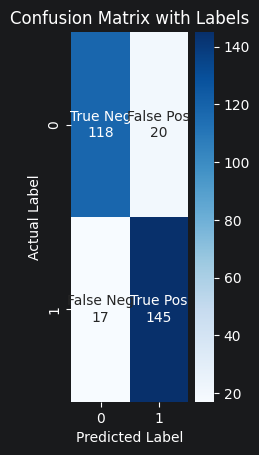

In [23]:

# 1. Calculate the raw confusion matrix numbers
cm = confusion_matrix(y_test, y_pred)

# 2. Create custom labels for each box
# We flatten the matrix to match labels to the four boxes
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]

# Combine names and counts (e.g., "True Neg\n120")
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2,2)

# 3. Plot the heatmap with the custom labels
plt.subplot(1, 3, 2)
sns.heatmap(cm, annot=labels, fmt="", cmap='Blues')
plt.title('Confusion Matrix with Labels')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

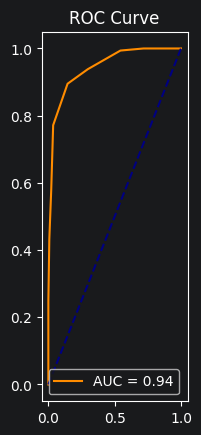

In [24]:
plt.subplot(1, 3, 3)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [25]:
print(f"Accuracy_Score:{accuracy_score(y_test, y_pred):.2f}")

Accuracy_Score:0.88


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86       138
           1       0.88      0.90      0.89       162

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



In [27]:
my_hours = [[1.2]]

prediction = model.predict(my_hours)

if prediction[0]==1:
    print("pass")
else:
    print("fail")

fail


C:\Users\priya\PycharmProjects\ML_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
